# Datos y modelo baseline en Keras

Carga, partición y normalización de MNIST; se inspecciona el balance de clases y se entrena un modelo base.


# Preparación de datos MNIST

# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN INICIAL
-NumPy y Pandas se utilizan para manipular datos y construir tablas de resultados.

-Matplotlib permite generar gráficas para analizar el entrenamiento de los modelos.

-TensorFlow/Keras se utiliza para construir, entrenar y evaluar redes neuronales.

-Scikit-learn aporta la división de datos y las métricas de clasificación.

-Se fija una semilla para intentar que los experimentos sean reproducibles.

In [16]:
# Librerías, semilla y carga de MNIST
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.21.0


# CARGA DEL CONJUNTO DE DATOS MNIST
MNIST contiene imágenes de dígitos escritos a mano del 0 al 9.
Se separan los datos originales de entrenamiento y de prueba.

"x" contiene las imágenes y "y" contiene la etiqueta numérica de cada imagen.
Las dimensiones permiten comprobar que las imágenes son de 28 x 28 píxeles.

In [17]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()
print("Train original:", x_train_full.shape, y_train_full.shape)
print("Test:", x_test.shape, y_test.shape)



Train original: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


# DIVISIÓN DEL CONJUNTO DE ENTRENAMIENTO

Se reserva el 20 % de los datos originales de entrenamiento para validación (dev).
El parámetro stratify mantiene una distribución de clases similar en ambos conjuntos.
random_state utiliza la semilla definida anteriormente para obtener una partición reproducible.
El conjunto de prueba permanece separado y no participa en el entrenamiento.

In [18]:
x_train, x_dev, y_train, y_dev = train_test_split(
    x_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

print("Train:", x_train.shape, y_train.shape)
print("Dev:", x_dev.shape, y_dev.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (48000, 28, 28) (48000,)
Dev: (12000, 28, 28) (12000,)
Test: (10000, 28, 28) (10000,)


# NORMALIZACIÓN DE LAS IMÁGENES
Los píxeles de MNIST están originalmente entre 0 y 255.
Se convierten a float32 y se dividen entre 255 para llevarlos al rango [0, 1].
La normalización facilita el entrenamiento de la red neuronal y mejora su estabilidad numérica.


In [19]:
x_train = x_train.astype("float32") / 255.0
x_dev = x_dev.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Rango train:", x_train.min(), x_train.max())

Rango train: 0.0 1.0


# ANÁLISIS DE LA DISTRIBUCIÓN DE CLASES
Esta función cuenta cuántos ejemplos existen de cada dígito entre 0 y 9.

np.bincount calcula las frecuencias y se fuerza a tener las 10 clases.
Después se calcula el porcentaje que representa cada clase.
Finalmente se construye una tabla para revisar si los conjuntos están balanceados.


In [20]:
def distribucion_clases(y, nombre):
    conteos = np.bincount(y, minlength=10)
    tabla = pd.DataFrame({"digito": np.arange(10), "cantidad": conteos,
                         "porcentaje": np.round(conteos / len(y) * 100, 2)})
    print(nombre)
    display(tabla)
    return tabla

dist_train = distribucion_clases(y_train, "TRAIN")
dist_dev = distribucion_clases(y_dev, "DEV")
dist_test = distribucion_clases(y_test, "TEST")


TRAIN


,digito,cantidad,porcentaje
0,0,4738,9.87
1,1,5394,11.24
2,2,4766,9.93
3,3,4905,10.22
4,4,4674,9.74
5,5,4337,9.04
6,6,4734,9.86
7,7,5012,10.44
8,8,4681,9.75
9,9,4759,9.91


DEV


,digito,cantidad,porcentaje
0,0,1185,9.88
1,1,1348,11.23
2,2,1192,9.93
3,3,1226,10.22
4,4,1168,9.73
5,5,1084,9.03
6,6,1184,9.87
7,7,1253,10.44
8,8,1170,9.75
9,9,1190,9.92


TEST


,digito,cantidad,porcentaje
0,0,980,9.80
1,1,1135,11.35
2,2,1032,10.32
3,3,1010,10.10
4,4,982,9.82
5,5,892,8.92
6,6,958,9.58
7,7,1028,10.28
8,8,974,9.74
9,9,1009,10.09


# MODELO BASELINE
Se define una red neuronal sencilla como punto de referencia.

Input recibe imágenes de 28 x 28 píxeles.

Flatten convierte cada imagen en un vector de 784 características.

Dense con ReLU crea una capa oculta de 128 neuronas.

La capa final tiene 10 neuronas y Softmax genera una probabilidad para cada dígito.

Adam se utiliza como optimizador por defecto cuando no se especifica otro.

sparse_categorical_crossentropy es adecuada porque las etiquetas son enteros 0-9.


In [21]:
def crear_modelo_baseline(units=128, optimizer=None):
    modelo = keras.Sequential([layers.Input(shape=(28, 28)), layers.Flatten(),
        layers.Dense(units, activation="relu"), layers.Dense(10, activation="softmax")])
    if optimizer is None:
        optimizer = keras.optimizers.Adam(learning_rate=0.001)
    modelo.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return modelo

modelo_base = crear_modelo_baseline()
modelo_base.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# ENTRENAMIENTO DEL MODELO BASELINE
Se entrena la red con los datos de entrenamiento.
validation_data permite medir el comportamiento sobre el conjunto de desarrollo.
Se utilizan 5 épocas y lotes de 64 imágenes.
El objeto hist_base guarda la evolución de loss y accuracy durante el entrenamiento.


In [22]:
hist_base = modelo_base.fit(x_train, y_train, validation_data=(x_dev, y_dev),
                           epochs=5, batch_size=64, verbose=1)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9096 - loss: 0.3258 - val_accuracy: 0.9448 - val_loss: 0.1918
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9570 - loss: 0.1499 - val_accuracy: 0.9579 - val_loss: 0.1503
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9700 - loss: 0.1056 - val_accuracy: 0.9594 - val_loss: 0.1345
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9767 - loss: 0.0805 - val_accuracy: 0.9617 - val_loss: 0.1254
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9819 - loss: 0.0634 - val_accuracy: 0.9634 - val_loss: 0.1224


# VISUALIZACIÓN DEL ENTRENAMIENTO BASELINE
La primera gráfica muestra la evolución de la pérdida (loss) en entrenamiento y validación.
La segunda gráfica muestra la evolución de accuracy en entrenamiento y validación.
Comparar ambas curvas ayuda a detectar aprendizaje insuficiente o sobreajuste.


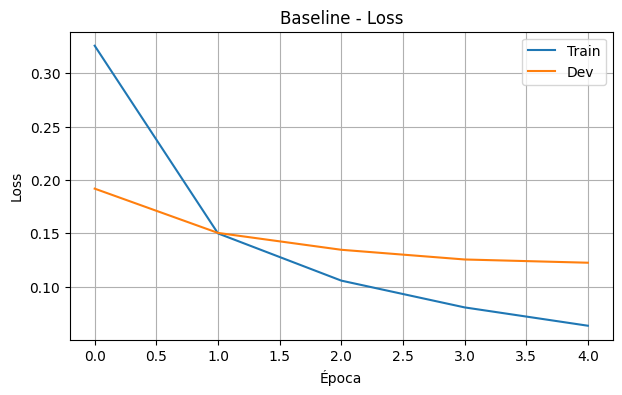

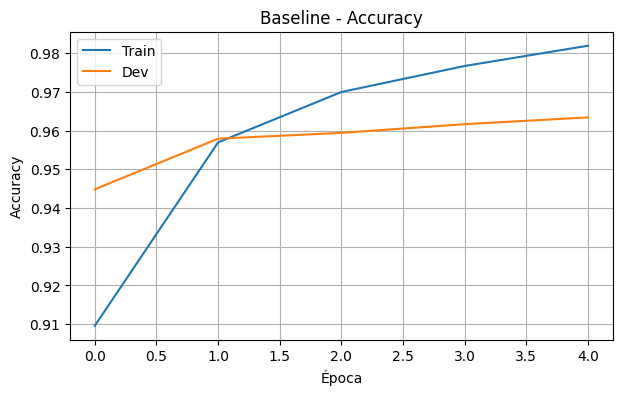

In [23]:
plt.figure(figsize=(7, 4))

plt.plot(hist_base.history["loss"], label="Train")

plt.plot(hist_base.history["val_loss"], label="Dev")

plt.xlabel("Época")

plt.ylabel("Loss")

plt.title("Baseline - Loss")

plt.legend()

plt.grid(True)

plt.show()



plt.figure(figsize=(7, 4))

plt.plot(hist_base.history["accuracy"], label="Train")

plt.plot(hist_base.history["val_accuracy"], label="Dev")

plt.xlabel("Época")

plt.ylabel("Accuracy")

plt.title("Baseline - Accuracy")

plt.legend()

plt.grid(True)

plt.show()
